
# DET-DA + Perfect Foresight Baseline
## Rye Microgrid — Pyomo + HiGHS

This notebook is the first **final research-code** step for the paper.

It implements:

1. data loading and parameter setup,
2. a common 24-hour MILP microgrid model,
3. **DET-DA** using controlled point forecasts,
4. realized-operation recourse with day-ahead DG commitment and BESS schedule retained,
5. **Perfect Foresight (PF)** using the measured realized trajectory,
6. validation checks for power balance, SOC, simultaneous charge/discharge, and grid exchange,
7. an optional batch experiment for the 127 held-out OOS days.

### Information structure used here

- **DET-DA:** point forecasts are used to choose day-ahead DG commitment and BESS charge/discharge schedule.
- **Realized DET operation:** day-ahead DG commitment and BESS schedule are retained; DG redispatch, grid exchange, renewable curtailment, and load shedding provide recourse.
- **PF:** uses the realized full-horizon PV, wind, and load trajectories.

This structure is intentionally kept aligned with the two-stage formulation that will later be used for STO-DA.


In [1]:

# Run this cell once if Pyomo / HiGHS are not installed in your Jupyter environment.
# In Anaconda Prompt / terminal you can alternatively run:
#     pip install pyomo highspy pandas numpy scipy matplotlib

%pip install -q pyomo highspy pandas numpy scipy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:

from pathlib import Path
import json
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

print("Pyomo version:", pyo.__version__ if hasattr(pyo, "__version__") else "installed")


Pyomo version: installed



## 1. Locate data and configuration

Recommended folder structure:

```text
project/
├── 03_DET_PF_Pyomo_HiGHS.ipynb
├── data/
│   ├── rye_development_304days.csv
│   └── rye_oos_127days.csv
└── config/
    └── study_parameters_frozen_v1.json
```

The cell below also works if the CSV/JSON files are placed directly beside the notebook.


In [3]:

ROOT = Path.cwd()

def find_file(filename):
    candidates = [
        ROOT / filename,
        ROOT / "data" / filename,
        ROOT / "config" / filename,
        Path("/mnt/data") / filename,   # useful in ChatGPT workspace
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not locate {filename}. Tried: {candidates}")

DEV_FILE = find_file("rye_development_304days.csv")
OOS_FILE = find_file("rye_oos_127days.csv")
PARAM_FILE = find_file("study_parameters_frozen_v1.json")

print("Development data:", DEV_FILE)
print("OOS data:", OOS_FILE)
print("Parameters:", PARAM_FILE)


Development data: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo_DET_PF_Step1\data\rye_development_304days.csv
OOS data: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo_DET_PF_Step1\data\rye_oos_127days.csv
Parameters: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo_DET_PF_Step1\config\study_parameters_frozen_v1.json


In [4]:

dev = pd.read_csv(DEV_FILE)
oos = pd.read_csv(OOS_FILE)

with open(PARAM_FILE, "r", encoding="utf-8") as f:
    CFG = json.load(f)

print("Development rows:", len(dev), "days:", dev["date_utc"].nunique())
print("OOS rows:", len(oos), "days:", oos["date_utc"].nunique())

display(dev.head())


Development rows: 7296 days: 304
OOS rows: 3048 days: 127


,time_utc,date_utc,hour_utc,split,source_file,pv_raw_kw,pv_clean_kw,wind_raw_kw,wind_clean_kw,load_kw,critical_load_kw,noncritical_load_kw,spot_price_nok_per_kwh,buy_price_nok_per_kwh,sell_price_nok_per_kwh
0,2020-01-02 00:00:00,2020-01-02,0,development,train,0.0,0.0,21.06,21.06,13.065960,4.311767,8.754193,0.12897,0.17897,0.143176
1,2020-01-02 01:00:00,2020-01-02,1,development,train,0.0,0.0,13.21,13.21,13.914830,4.591894,9.322936,0.18732,0.23732,0.189856
2,2020-01-02 02:00:00,2020-01-02,2,development,train,0.0,0.0,12.45,12.45,14.094724,4.651259,9.443465,0.20746,0.25746,0.205968
3,2020-01-02 03:00:00,2020-01-02,3,development,train,0.0,0.0,9.24,9.24,14.121581,4.660122,9.461459,0.23860,0.28860,0.230880
4,2020-01-02 04:00:00,2020-01-02,4,development,train,0.0,0.0,4.82,4.82,13.452862,4.439445,9.013418,0.25804,0.30804,0.246432



## 2. Final study parameters used in this notebook

The original Rye system provides the real PV, wind, BESS, load, and spot-price data.  
The DG and bidirectional export interface are **study extensions** required by the paper's methodology.

For the battery, this notebook follows the Rye simulator convention in which the documented 85% round-trip loss is placed on charging:

\[
SOC_{t+1}=SOC_t+\frac{0.85P_t^{ch}\Delta t}{E_B}
-\frac{P_t^{dis}\Delta t}{E_B}.
\]


In [5]:

# Time
T = CFG["time"]["T_hours"]
DT = CFG["time"]["delta_t_h"]

# Rye physical system
PV_RATED = CFG["rye_physical_system"]["pv_rated_kwp"]
WIND_RATED = CFG["rye_physical_system"]["wind_rated_kw"]
BESS_E = CFG["rye_physical_system"]["bess_energy_kwh"]
P_CH_MAX = CFG["rye_physical_system"]["bess_charge_max_kw"]
P_DIS_MAX = CFG["rye_physical_system"]["bess_discharge_max_kw"]
ETA_CH = CFG["rye_physical_system"]["eta_charge"]
ETA_DIS = CFG["rye_physical_system"]["eta_discharge"]

# SOC
SOC_MIN = CFG["bess_study_settings"]["soc_min"]
SOC_MAX = CFG["bess_study_settings"]["soc_max"]
SOC_INIT = CFG["bess_study_settings"]["soc_initial"]
SOC_TERM = CFG["bess_study_settings"]["soc_terminal"]

# DG
DG_MIN = CFG["study_added_diesel_generator"]["p_min_kw"]
DG_MAX = CFG["study_added_diesel_generator"]["p_max_kw"]
C_DG = CFG["study_added_diesel_generator"]["marginal_cost_nok_per_kwh"]

# Grid
GRID_IMPORT_MAX = CFG["grid"]["import_max_kw"]
GRID_EXPORT_MAX = CFG["grid"]["export_max_kw"]
GRID_ENERGY_TARIFF = CFG["grid"]["energy_tariff_nok_per_kwh"]
SELL_FACTOR = CFG["grid"]["sell_price_fraction_of_buy"]

# Load priority
CRIT_SHARE = CFG["load_priority"]["critical_fraction"]
NCRIT_SHARE = CFG["load_priority"]["noncritical_fraction"]

# Objective penalties
C_BATT = CFG["objective_coefficients"]["battery_throughput_nok_per_kwh"]
C_CURT = CFG["objective_coefficients"]["renewable_curtailment_nok_per_kwh"]
C_SHED_N = CFG["objective_coefficients"]["noncritical_shedding_penalty_nok_per_kwh"]
C_SHED_C = CFG["objective_coefficients"]["critical_shedding_penalty_nok_per_kwh"]

ALPHAS = CFG["uncertainty"]["alpha_levels"]
BASE_SEED = CFG["uncertainty"]["random_seed"]

print({
    "PV_RATED_kWp": PV_RATED,
    "WIND_RATED_kW": WIND_RATED,
    "BESS_kWh": BESS_E,
    "DG_min_max_kW": (DG_MIN, DG_MAX),
    "SOC_bounds": (SOC_MIN, SOC_MAX),
    "sell_factor": SELL_FACTOR,
    "alphas": ALPHAS,
})


{'PV_RATED_kWp': 86.4, 'WIND_RATED_kW': 225.0, 'BESS_kWh': 500.0, 'DG_min_max_kW': (5.0, 50.0), 'SOC_bounds': (0.22, 1.0), 'sell_factor': 0.2, 'alphas': [0.05, 0.1, 0.2, 0.3]}



## 3. Prepare one 24-hour day

`spot_price_nok_per_kwh` is taken from the real Rye data.  
The study purchase price is

\[
c_t^{buy}=c_t^{spot}+0.05,
\]

and the study export credit is

\[
c_t^{sell}=0.2c_t^{buy}.
\]

The original preprocessed CSV may contain an older exploratory sell-price column; this notebook **does not use it**.


In [6]:

def get_day(df, date_string):
    x = df[df["date_utc"].astype(str) == str(date_string)].copy()
    x = x.sort_values("hour_utc")
    if len(x) != 24:
        raise ValueError(f"{date_string} has {len(x)} rows; expected 24.")

    day = pd.DataFrame({
        "hour": np.arange(24),
        "pv": x["pv_clean_kw"].to_numpy(float),
        "wind": x["wind_clean_kw"].to_numpy(float),
        "load": x["load_kw"].to_numpy(float),
        "spot": x["spot_price_nok_per_kwh"].to_numpy(float),
    })
    day["buy_price"] = day["spot"] + GRID_ENERGY_TARIFF
    day["sell_price"] = SELL_FACTOR * day["buy_price"]
    day["load_crit"] = CRIT_SHARE * day["load"]
    day["load_ncrit"] = NCRIT_SHARE * day["load"]
    return day

REP_DAY = "2020-03-26"
actual_day = get_day(dev, REP_DAY)
display(actual_day.head())


,hour,pv,wind,load,spot,buy_price,sell_price,load_crit,load_ncrit
0,0,0.0,0.00,21.243311,0.07285,0.12285,0.024570,7.010293,14.233018
1,1,0.0,0.75,20.937647,0.07344,0.12344,0.024688,6.909423,14.028223
2,2,0.0,7.36,18.540378,0.07473,0.12473,0.024946,6.118325,12.422053
3,3,0.0,6.85,18.791929,0.07614,0.12614,0.025228,6.201337,12.590592
4,4,0.0,7.90,18.278013,0.07744,0.12744,0.025488,6.031744,12.246269



## 4. Controlled point-forecast generation

The measured trajectory remains the realized ground truth.

To construct a controlled point forecast consistent with the paper's normalized error definition,

\[
X_t^{real}=\hat X_t(1+e_t),\qquad
e_t\sim\mathcal N(0,\alpha^2),
\]

the forecast is generated as

\[
\hat X_t=\frac{X_t^{real}}{1+e_t}.
\]

A lower bound on \(e_t\) is used only to avoid division close to zero, and renewable forecasts are clipped to documented physical ratings.


In [7]:

def make_controlled_forecast(actual, alpha, seed):
    rng = np.random.default_rng(seed)
    fc = actual.copy()

    for col, cap in [("pv", PV_RATED), ("wind", WIND_RATED), ("load", None)]:
        realized = actual[col].to_numpy(float)
        e = rng.normal(0.0, alpha, size=24)

        # Numerical safeguard only; the main alpha range is 0.05--0.30.
        e = np.clip(e, -0.80, 1.50)

        forecast = realized / (1.0 + e)
        forecast = np.maximum(forecast, 0.0)
        if cap is not None:
            forecast = np.minimum(forecast, cap)

        fc[col] = forecast

    fc["load_crit"] = CRIT_SHARE * fc["load"]
    fc["load_ncrit"] = NCRIT_SHARE * fc["load"]

    # Prices are assumed known day-ahead in this study.
    fc["spot"] = actual["spot"].to_numpy(float)
    fc["buy_price"] = actual["buy_price"].to_numpy(float)
    fc["sell_price"] = actual["sell_price"].to_numpy(float)
    return fc

alpha_demo = 0.20
forecast_day = make_controlled_forecast(actual_day, alpha_demo, BASE_SEED)
display(forecast_day.head())


,hour,pv,wind,load,spot,buy_price,sell_price,load_crit,load_ncrit
0,0,0.0,0.000000,18.703675,0.07285,0.12285,0.024570,6.172213,12.531462
1,1,0.0,0.806822,20.658431,0.07344,0.12344,0.024688,6.817282,13.841149
2,2,0.0,6.651834,17.526904,0.07473,0.12473,0.024946,5.783878,11.743026
3,3,0.0,6.383442,16.685284,0.07614,0.12614,0.025228,5.506144,11.179140
4,4,0.0,7.297608,25.795678,0.07744,0.12744,0.025488,8.512574,17.283104



## 5. Common Pyomo MILP model

The same physical model is used for DET-DA and PF.

The model includes:

- PV and wind availability/curtailment,
- DG commitment and dispatch,
- BESS SOC dynamics,
- mutually exclusive charging/discharging,
- critical and non-critical shedding,
- mutually exclusive grid import/export,
- grid-connected (`GC`) and islanded (`IS`) modes,
- terminal SOC equality for fair comparison.


In [8]:

def get_highs_solver():
    # appsi_highs is preferred when highspy is installed.
    for name in ("appsi_highs", "highs"):
        try:
            solver = pyo.SolverFactory(name)
            if solver is not None and solver.available(exception_flag=False):
                print("Using solver:", name)
                return solver
        except Exception:
            pass
    raise RuntimeError(
        "HiGHS was not found. Run: pip install pyomo highspy"
    )

solver = get_highs_solver()


Using solver: appsi_highs


In [9]:

def build_microgrid_model(
    day,
    mode="GC",
    fixed_u_dg=None,
    fixed_y_b=None,
    fixed_p_ch=None,
    fixed_p_dis=None,
):
    if mode not in {"GC", "IS"}:
        raise ValueError("mode must be 'GC' or 'IS'")

    m = pyo.ConcreteModel(name=f"Rye_{mode}")
    m.T = pyo.RangeSet(0, 23)
    m.Tsoc = pyo.RangeSet(0, 24)

    # -------- Parameters --------
    pv = dict(enumerate(day["pv"].to_numpy(float)))
    wind = dict(enumerate(day["wind"].to_numpy(float)))
    load = dict(enumerate(day["load"].to_numpy(float)))
    lcrit = dict(enumerate(day["load_crit"].to_numpy(float)))
    lncrit = dict(enumerate(day["load_ncrit"].to_numpy(float)))
    buy_price = dict(enumerate(day["buy_price"].to_numpy(float)))
    sell_price = dict(enumerate(day["sell_price"].to_numpy(float)))

    m.PV_av = pyo.Param(m.T, initialize=pv, within=pyo.NonNegativeReals)
    m.W_av = pyo.Param(m.T, initialize=wind, within=pyo.NonNegativeReals)
    m.Load = pyo.Param(m.T, initialize=load, within=pyo.NonNegativeReals)
    m.Lcrit = pyo.Param(m.T, initialize=lcrit, within=pyo.NonNegativeReals)
    m.Lncrit = pyo.Param(m.T, initialize=lncrit, within=pyo.NonNegativeReals)
    m.cbuy = pyo.Param(m.T, initialize=buy_price)
    m.csell = pyo.Param(m.T, initialize=sell_price)

    g = 1 if mode == "GC" else 0

    # -------- Variables --------
    m.P_pv = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_wind = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    m.P_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.Tsoc, bounds=(SOC_MIN, SOC_MAX))

    m.P_buy = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    m.P_shed_c = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_shed_n = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_curt = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    m.u_dg = pyo.Var(m.T, domain=pyo.Binary)
    m.y_b = pyo.Var(m.T, domain=pyo.Binary)  # 1=charge, 0=discharge
    m.z_g = pyo.Var(m.T, domain=pyo.Binary)  # 1=import, 0=export

    # -------- Objective --------
    def objective_rule(m):
        return sum(
            m.cbuy[t] * m.P_buy[t]
            - m.csell[t] * m.P_sell[t]
            + C_DG * m.P_dg[t]
            + C_BATT * (m.P_ch[t] + m.P_dis[t])
            + C_CURT * m.P_curt[t]
            + C_SHED_C * m.P_shed_c[t]
            + C_SHED_N * m.P_shed_n[t]
            for t in m.T
        ) * DT

    m.cost = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # -------- Renewable limits --------
    m.pv_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_pv[t] <= m.PV_av[t]
    )
    m.wind_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_wind[t] <= m.W_av[t]
    )
    m.curtailment_def = pyo.Constraint(
        m.T,
        rule=lambda m,t:
            m.P_curt[t] == (m.PV_av[t] - m.P_pv[t]) + (m.W_av[t] - m.P_wind[t])
    )

    # -------- DG --------
    m.dg_min = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dg[t] >= DG_MIN * m.u_dg[t]
    )
    m.dg_max = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dg[t] <= DG_MAX * m.u_dg[t]
    )

    # -------- BESS --------
    m.soc_initial = pyo.Constraint(expr=m.SOC[0] == SOC_INIT)
    m.soc_terminal = pyo.Constraint(expr=m.SOC[24] == SOC_TERM)

    def soc_rule(m, t):
        return m.SOC[t+1] == (
            m.SOC[t]
            + ETA_CH * m.P_ch[t] * DT / BESS_E
            - m.P_dis[t] * DT / (ETA_DIS * BESS_E)
        )
    m.soc_dyn = pyo.Constraint(m.T, rule=soc_rule)

    m.charge_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_ch[t] <= P_CH_MAX * m.y_b[t]
    )
    m.discharge_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dis[t] <= P_DIS_MAX * (1 - m.y_b[t])
    )

    # -------- Load shedding --------
    m.shed_c_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_shed_c[t] <= m.Lcrit[t]
    )
    m.shed_n_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_shed_n[t] <= m.Lncrit[t]
    )

    # -------- Grid --------
    m.buy_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_buy[t] <= g * GRID_IMPORT_MAX * m.z_g[t]
    )
    m.sell_limit = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_sell[t] <= g * GRID_EXPORT_MAX * (1 - m.z_g[t])
    )

    # -------- Hourly power balance --------
    def balance_rule(m, t):
        return (
            m.P_pv[t] + m.P_wind[t] + m.P_dg[t]
            + m.P_dis[t] + m.P_buy[t]
            ==
            m.Load[t] - m.P_shed_c[t] - m.P_shed_n[t]
            + m.P_ch[t] + m.P_sell[t]
        )
    m.balance = pyo.Constraint(m.T, rule=balance_rule)

    # -------- Optional fixed day-ahead decisions --------
    if fixed_u_dg is not None:
        for t in range(24):
            m.u_dg[t].fix(int(round(float(fixed_u_dg[t]))))

    if fixed_y_b is not None:
        for t in range(24):
            m.y_b[t].fix(int(round(float(fixed_y_b[t]))))

    if fixed_p_ch is not None:
        for t in range(24):
            m.P_ch[t].fix(float(fixed_p_ch[t]))

    if fixed_p_dis is not None:
        for t in range(24):
            m.P_dis[t].fix(float(fixed_p_dis[t]))

    return m


In [10]:

def solve_model(model, tee=False):
    t0 = time.perf_counter()
    result = solver.solve(model, tee=tee)
    elapsed = time.perf_counter() - t0

    term = str(result.solver.termination_condition).lower()
    if "optimal" not in term:
        raise RuntimeError(
            f"Solver termination: {result.solver.termination_condition}"
        )
    return result, elapsed


def extract_solution(m):
    rows = []
    for t in range(24):
        rows.append({
            "hour": t,
            "pv": pyo.value(m.P_pv[t]),
            "wind": pyo.value(m.P_wind[t]),
            "dg": pyo.value(m.P_dg[t]),
            "charge": pyo.value(m.P_ch[t]),
            "discharge": pyo.value(m.P_dis[t]),
            "soc_start": pyo.value(m.SOC[t]),
            "buy": pyo.value(m.P_buy[t]),
            "sell": pyo.value(m.P_sell[t]),
            "shed_crit": pyo.value(m.P_shed_c[t]),
            "shed_ncrit": pyo.value(m.P_shed_n[t]),
            "curtailment": pyo.value(m.P_curt[t]),
            "u_dg": pyo.value(m.u_dg[t]),
            "y_b": pyo.value(m.y_b[t]),
            "z_g": pyo.value(m.z_g[t]),
        })
    df = pd.DataFrame(rows)
    df["soc_end"] = [pyo.value(m.SOC[t+1]) for t in range(24)]
    return df


def solution_metrics(model, solution_df):
    # Reconstruct balance residual from solved variables and model load parameter.
    load = np.array([pyo.value(model.Load[t]) for t in model.T], dtype=float)
    lhs = (
        solution_df["pv"] + solution_df["wind"] + solution_df["dg"]
        + solution_df["discharge"] + solution_df["buy"]
    )
    rhs = (
        load - solution_df["shed_crit"] - solution_df["shed_ncrit"]
        + solution_df["charge"] + solution_df["sell"]
    )

    return {
        "cost_nok": float(pyo.value(model.cost)),
        "max_power_balance_residual_kw": float(np.max(np.abs(lhs-rhs))),
        "terminal_soc": float(pyo.value(model.SOC[24])),
        "critical_eens_kwh": float(solution_df["shed_crit"].sum() * DT),
        "noncritical_eens_kwh": float(solution_df["shed_ncrit"].sum() * DT),
        "diesel_energy_kwh": float(solution_df["dg"].sum() * DT),
        "battery_throughput_kwh": float(
            (solution_df["charge"] + solution_df["discharge"]).sum() * DT
        ),
        "curtailment_kwh": float(solution_df["curtailment"].sum() * DT),
        "grid_import_kwh": float(solution_df["buy"].sum() * DT),
        "grid_export_kwh": float(solution_df["sell"].sum() * DT),
        "max_simultaneous_charge_discharge_kw": float(
            np.max(np.minimum(solution_df["charge"], solution_df["discharge"]))
        ),
        "max_simultaneous_buy_sell_kw": float(
            np.max(np.minimum(solution_df["buy"], solution_df["sell"]))
        ),
    }



## 6. DET-DA and realized-operation evaluation

Step 1: solve the 24-hour day-ahead MILP using the point forecast.

Step 2: expose the day-ahead policy to the measured realized trajectory.

The following **day-ahead decisions are retained** in realized operation:

- DG commitment \(u_t^{DG}\),
- battery operating mode \(y_t^B\) (charge or discharge).

The following power magnitudes are allowed to adapt in real time:

- DG redispatch inside the committed range,
- BESS charging/discharging power inside the retained operating mode,
- grid import/export in GC mode,
- renewable curtailment,
- critical/non-critical load shedding.

This recourse partition prevents artificial infeasibility under large forecast errors while still preserving non-anticipative day-ahead commitment/mode decisions. The same partition should later be used consistently in STO-DA.


In [11]:

def run_det(actual, forecast, mode="GC"):
    # Day-ahead forecast optimization
    m_da = build_microgrid_model(forecast, mode=mode)
    _, t_da = solve_model(m_da)
    da = extract_solution(m_da)

    # Realized operation:
    # retain day-ahead DG commitment and battery operating mode,
    # but allow dispatch magnitudes to adapt to the realization.
    m_real = build_microgrid_model(
        actual,
        mode=mode,
        fixed_u_dg=da["u_dg"].to_numpy(),
        fixed_y_b=da["y_b"].to_numpy(),
    )
    _, t_real = solve_model(m_real)
    realized = extract_solution(m_real)

    return {
        "day_ahead_model": m_da,
        "day_ahead_solution": da,
        "day_ahead_cost_nok": float(pyo.value(m_da.cost)),
        "realized_model": m_real,
        "realized_solution": realized,
        "realized_metrics": solution_metrics(m_real, realized),
        "solve_time_s": t_da + t_real,
    }


def run_pf(actual, mode="GC"):
    m = build_microgrid_model(actual, mode=mode)
    _, t = solve_model(m)
    sol = extract_solution(m)
    return {
        "model": m,
        "solution": sol,
        "metrics": solution_metrics(m, sol),
        "solve_time_s": t,
    }



## 7. Representative-day validation

This is **not a paper result**. It is a model sanity check before running the held-out OOS experiment.


In [12]:

demo_rows = []

for mode in ["GC", "IS"]:
    det = run_det(actual_day, forecast_day, mode=mode)
    pf = run_pf(actual_day, mode=mode)

    det_m = det["realized_metrics"]
    pf_m = pf["metrics"]

    demo_rows.append({
        "date": REP_DAY,
        "mode": mode,
        "alpha": alpha_demo,
        "det_day_ahead_cost_nok": det["day_ahead_cost_nok"],
        "det_realized_cost_nok": det_m["cost_nok"],
        "pf_cost_nok": pf_m["cost_nok"],
        "det_minus_pf_nok": det_m["cost_nok"] - pf_m["cost_nok"],
        "det_critical_eens_kwh": det_m["critical_eens_kwh"],
        "det_noncritical_eens_kwh": det_m["noncritical_eens_kwh"],
        "pf_critical_eens_kwh": pf_m["critical_eens_kwh"],
        "pf_noncritical_eens_kwh": pf_m["noncritical_eens_kwh"],
        "det_terminal_soc": det_m["terminal_soc"],
        "pf_terminal_soc": pf_m["terminal_soc"],
        "det_balance_residual_kw": det_m["max_power_balance_residual_kw"],
        "pf_balance_residual_kw": pf_m["max_power_balance_residual_kw"],
    })

demo_results = pd.DataFrame(demo_rows)
display(demo_results)


,date,mode,alpha,det_day_ahead_cost_nok,det_realized_cost_nok,pf_cost_nok,det_minus_pf_nok,det_critical_eens_kwh,det_noncritical_eens_kwh,pf_critical_eens_kwh,pf_noncritical_eens_kwh,det_terminal_soc,pf_terminal_soc,det_balance_residual_kw,pf_balance_residual_kw
0,2020-03-26,GC,0.2,25.929826,23.495123,23.495123,3.552714e-15,0.0,0.000000,0.0,0.0,0.5,0.5,3.552714e-15,0.000000e+00
1,2020-03-26,IS,0.2,625.783126,524.416377,511.129606,1.328677e+01,0.0,1.120118,0.0,0.0,0.5,0.5,7.105427e-15,3.552714e-15


In [13]:

# Hard validation checks
TOL = 1e-5

assert (demo_results["pf_cost_nok"] <= demo_results["det_realized_cost_nok"] + TOL).all(), \
    "PF should not be more expensive than DET realized operation."

assert (np.abs(demo_results["det_terminal_soc"] - SOC_TERM) <= TOL).all()
assert (np.abs(demo_results["pf_terminal_soc"] - SOC_TERM) <= TOL).all()

assert (demo_results["det_balance_residual_kw"] <= TOL).all()
assert (demo_results["pf_balance_residual_kw"] <= TOL).all()

print("Representative-day validation PASSED.")


Representative-day validation PASSED.


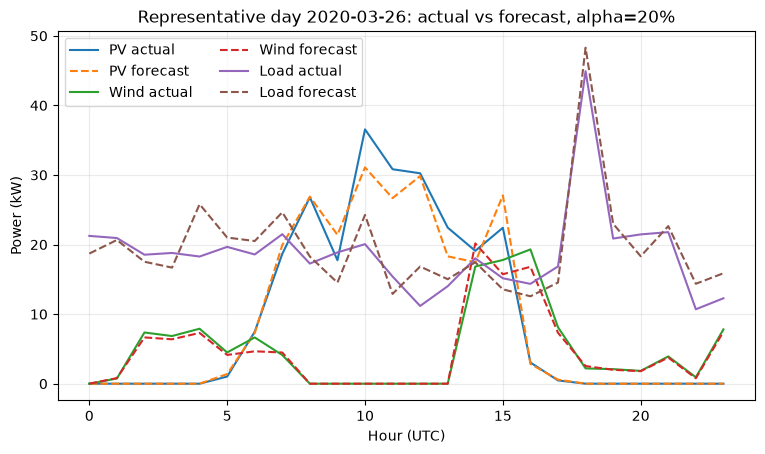

In [14]:

# Visual check: real trajectory vs controlled forecast
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(actual_day["hour"], actual_day["pv"], label="PV actual")
ax.plot(forecast_day["hour"], forecast_day["pv"], "--", label="PV forecast")
ax.plot(actual_day["hour"], actual_day["wind"], label="Wind actual")
ax.plot(forecast_day["hour"], forecast_day["wind"], "--", label="Wind forecast")
ax.plot(actual_day["hour"], actual_day["load"], label="Load actual")
ax.plot(forecast_day["hour"], forecast_day["load"], "--", label="Load forecast")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Power (kW)")
ax.set_title(f"Representative day {REP_DAY}: actual vs forecast, alpha={alpha_demo:.0%}")
ax.grid(alpha=0.25)
ax.legend(ncol=2)
plt.show()



## 8. Optional 127-day OOS DET/PF batch experiment

Run this only after the representative-day validation passes.

For reproducibility, each \((\text{date},\alpha)\) pair is assigned a deterministic seed.

PF does not depend on \(\alpha\), so PF is solved once per day and mode and then reused for all uncertainty levels.


In [15]:

def stable_seed(date_string, alpha, base_seed=BASE_SEED):
    # Avoid Python's randomized hash(); use a deterministic arithmetic seed.
    date_num = int(str(date_string).replace("-", ""))
    alpha_num = int(round(alpha * 1000))
    return (base_seed + date_num * 1009 + alpha_num * 9176) % (2**32 - 1)


def run_det_pf_oos_batch(oos_df, alphas=ALPHAS, modes=("GC","IS")):
    dates = sorted(oos_df["date_utc"].astype(str).unique())

    # PF cache: actual future, therefore no alpha dependence.
    pf_cache = {}
    rows = []

    for i, date in enumerate(dates, start=1):
        actual = get_day(oos_df, date)

        for mode in modes:
            pf = run_pf(actual, mode=mode)
            pf_cache[(date, mode)] = pf

        for alpha in alphas:
            forecast = make_controlled_forecast(
                actual,
                alpha=alpha,
                seed=stable_seed(date, alpha)
            )

            for mode in modes:
                det = run_det(actual, forecast, mode=mode)
                pf = pf_cache[(date, mode)]

                dm = det["realized_metrics"]
                pm = pf["metrics"]

                rows.append({
                    "date": date,
                    "mode": mode,
                    "alpha": alpha,
                    "det_cost_nok": dm["cost_nok"],
                    "pf_cost_nok": pm["cost_nok"],
                    "cou_nok": dm["cost_nok"] - pm["cost_nok"],
                    "det_critical_eens_kwh": dm["critical_eens_kwh"],
                    "det_noncritical_eens_kwh": dm["noncritical_eens_kwh"],
                    "pf_critical_eens_kwh": pm["critical_eens_kwh"],
                    "pf_noncritical_eens_kwh": pm["noncritical_eens_kwh"],
                    "det_diesel_kwh": dm["diesel_energy_kwh"],
                    "pf_diesel_kwh": pm["diesel_energy_kwh"],
                    "det_curtailment_kwh": dm["curtailment_kwh"],
                    "pf_curtailment_kwh": pm["curtailment_kwh"],
                    "det_grid_import_kwh": dm["grid_import_kwh"],
                    "det_grid_export_kwh": dm["grid_export_kwh"],
                    "det_solve_time_s": det["solve_time_s"],
                    "pf_solve_time_s": pf["solve_time_s"],
                })

        if i % 10 == 0 or i == len(dates):
            print(f"Completed {i}/{len(dates)} OOS days")

    return pd.DataFrame(rows)

batch = run_det_pf_oos_batch(oos)
batch.to_csv("det_pf_oos_results.csv", index=False)
display(batch.head())


Completed 10/127 OOS days
Completed 20/127 OOS days
Completed 30/127 OOS days
Completed 40/127 OOS days
Completed 50/127 OOS days
Completed 60/127 OOS days
Completed 70/127 OOS days
Completed 80/127 OOS days
Completed 90/127 OOS days
Completed 100/127 OOS days
Completed 110/127 OOS days
Completed 120/127 OOS days
Completed 127/127 OOS days


,date,mode,alpha,det_cost_nok,pf_cost_nok,cou_nok,det_critical_eens_kwh,det_noncritical_eens_kwh,pf_critical_eens_kwh,pf_noncritical_eens_kwh,det_diesel_kwh,pf_diesel_kwh,det_curtailment_kwh,pf_curtailment_kwh,det_grid_import_kwh,det_grid_export_kwh,det_solve_time_s,pf_solve_time_s
0,2020-11-01,GC,0.05,-27.918323,-27.918323,1.207923e-13,0.0,0.0,0.0,0.0,0.0,-2.842171e-14,170.677324,170.677324,0.0,2041.331874,0.110059,0.053434
1,2020-11-01,IS,0.05,221.200920,221.200920,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,2212.009199,2212.009199,0.0,0.000000,0.080018,0.046318
2,2020-11-01,GC,0.10,-27.918323,-27.918323,1.207923e-13,0.0,0.0,0.0,0.0,0.0,-2.842171e-14,170.677324,170.677324,0.0,2041.331874,0.089033,0.053434
3,2020-11-01,IS,0.10,221.200920,221.200920,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,2212.009199,2212.009199,0.0,0.000000,0.082114,0.046318
4,2020-11-01,GC,0.20,-27.918323,-27.918323,1.207923e-13,0.0,0.0,0.0,0.0,0.0,-2.842171e-14,170.677324,170.677324,0.0,2041.331874,0.087103,0.053434



## 9. CoU summary and paired 95% confidence intervals

After the batch run, the core DET/PF baseline quantities are

\[
CoU=\bar C_{DET}-\bar C_{PF}
\]

and

\[
CoU_\%=\frac{\bar C_{DET}-\bar C_{PF}}{\bar C_{PF}}\times100\%.
\]

Because DET and PF are evaluated on the **same held-out days**, confidence intervals should be formed from the paired daily cost differences.


In [16]:

from scipy import stats

def paired_mean_ci(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    se = stats.sem(x)
    if n < 2 or not np.isfinite(se):
        return m, np.nan, np.nan
    h = stats.t.ppf((1 + confidence) / 2, n - 1) * se
    return m, m - h, m + h


def summarize_det_pf(batch):
    summaries = []

    for (mode, alpha), g in batch.groupby(["mode", "alpha"]):
        diff = g["det_cost_nok"] - g["pf_cost_nok"]
        cou, ci_lo, ci_hi = paired_mean_ci(diff, 0.95)

        det_mean = g["det_cost_nok"].mean()
        pf_mean = g["pf_cost_nok"].mean()

        summaries.append({
            "mode": mode,
            "alpha": alpha,
            "det_mean_cost_nok": det_mean,
            "pf_mean_cost_nok": pf_mean,
            "cou_nok": cou,
            "cou_ci95_low": ci_lo,
            "cou_ci95_high": ci_hi,
            "cou_percent": 100 * cou / pf_mean if pf_mean != 0 else np.nan,
            "det_mean_critical_eens_kwh": g["det_critical_eens_kwh"].mean(),
            "det_mean_noncritical_eens_kwh": g["det_noncritical_eens_kwh"].mean(),
        })

    return pd.DataFrame(summaries)

summary = summarize_det_pf(batch)
summary.to_csv("det_pf_cou_summary.csv", index=False)
display(summary)


,mode,alpha,det_mean_cost_nok,pf_mean_cost_nok,cou_nok,cou_ci95_low,cou_ci95_high,cou_percent,det_mean_critical_eens_kwh,det_mean_noncritical_eens_kwh
0,GC,0.05,150.124597,150.116163,0.008434,-0.001687,0.018555,0.005618,0.000000,0.000000
1,GC,0.10,150.233937,150.116163,0.117774,0.041633,0.193915,0.078455,0.000000,0.000000
2,GC,0.20,150.418160,150.116163,0.301997,0.123424,0.480570,0.201176,0.000000,0.000000
3,GC,0.30,150.754497,150.116163,0.638334,0.240518,1.036149,0.425226,0.000000,0.000000
4,IS,0.05,1724.309920,1719.497658,4.812263,2.401524,7.223001,0.279864,0.000000,0.749512
5,IS,0.10,1738.334236,1719.497658,18.836578,11.592523,26.080633,1.095470,0.000000,2.554738
6,IS,0.20,1793.875464,1719.497658,74.377807,49.975015,98.780598,4.325554,0.000000,10.011549
7,IS,0.30,1837.266813,1719.497658,117.769155,86.532018,149.006292,6.849044,0.008688,14.792436



## Next research-code step

Once the 127-day DET/PF batch passes all sanity checks:

1. freeze the baseline,
2. implement Monte Carlo scenario generation,
3. implement Backward Reduction Algorithm,
4. build two-stage STO-DA in Pyomo,
5. perform scenario-count convergence,
6. then implement rolling-horizon MPC.

Do **not** start interpreting paper results until the full held-out batch has been validated.


In [17]:
tol = 1e-5

violations = batch[
    batch["pf_cost_nok"] > batch["det_cost_nok"] + tol
]

print("PF > DET violations:", len(violations))

PF > DET violations: 0


In [18]:
diagnostic = (
    batch.groupby(["mode", "alpha"])
    .agg(
        mean_cou=("cou_nok", "mean"),
        median_cou=("cou_nok", "median"),
        max_cou=("cou_nok", "max"),
        positive_cou_days=("cou_nok", lambda x: (x > 1e-5).sum()),
        total_days=("cou_nok", "size"),
    )
    .reset_index()
)

display(diagnostic)

,mode,alpha,mean_cou,median_cou,max_cou,positive_cou_days,total_days
0,GC,0.05,0.008434,0.000000e+00,0.579835,8,127
1,GC,0.10,0.117774,0.000000e+00,3.378608,20,127
2,GC,0.20,0.301997,0.000000e+00,6.513693,26,127
3,GC,0.30,0.638334,0.000000e+00,18.530150,31,127
4,IS,0.05,4.812263,0.000000e+00,86.240175,39,127
5,IS,0.10,18.836578,4.547474e-13,310.625358,57,127
6,IS,0.20,74.377807,9.492335e+00,933.865376,72,127
7,IS,0.30,117.769155,4.486504e+01,1120.461101,83,127


In [19]:
reliability = (
    batch.groupby(["mode", "alpha"])
    .agg(
        mean_critical_eens=("det_critical_eens_kwh", "mean"),
        mean_noncritical_eens=("det_noncritical_eens_kwh", "mean"),
        critical_interruption_days=(
            "det_critical_eens_kwh",
            lambda x: (x > 1e-6).sum()
        ),
        noncritical_interruption_days=(
            "det_noncritical_eens_kwh",
            lambda x: (x > 1e-6).sum()
        ),
    )
    .reset_index()
)

display(reliability)

,mode,alpha,mean_critical_eens,mean_noncritical_eens,critical_interruption_days,noncritical_interruption_days
0,GC,0.05,0.000000,0.000000,0,0
1,GC,0.10,0.000000,0.000000,0,0
2,GC,0.20,0.000000,0.000000,0,0
3,GC,0.30,0.000000,0.000000,0,0
4,IS,0.05,0.000000,0.749512,0,25
5,IS,0.10,0.000000,2.554738,0,35
6,IS,0.20,0.000000,10.011549,0,60
7,IS,0.30,0.008688,14.792436,1,65


In [20]:
negative_costs = (
    batch.groupby(["mode", "alpha"])
    .agg(
        negative_det_days=("det_cost_nok", lambda x: (x < 0).sum()),
        min_det_cost=("det_cost_nok", "min"),
        mean_grid_export=("det_grid_export_kwh", "mean"),
    )
    .reset_index()
)

display(negative_costs)

,mode,alpha,negative_det_days,min_det_cost,mean_grid_export
0,GC,0.05,15,-45.925436,189.295401
1,GC,0.10,15,-45.925436,189.961162
2,GC,0.20,15,-46.415880,191.316286
3,GC,0.30,15,-46.030181,192.240226
4,IS,0.05,0,39.821224,0.000000
5,IS,0.10,0,34.974465,0.000000
6,IS,0.20,0,34.974465,0.000000
7,IS,0.30,0,34.974465,0.000000


In [21]:
batch.loc[batch["cou_nok"].abs() < 1e-8, "cou_nok"] = 0.0